In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import copy

In [2]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Шум Гаусса

In [3]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

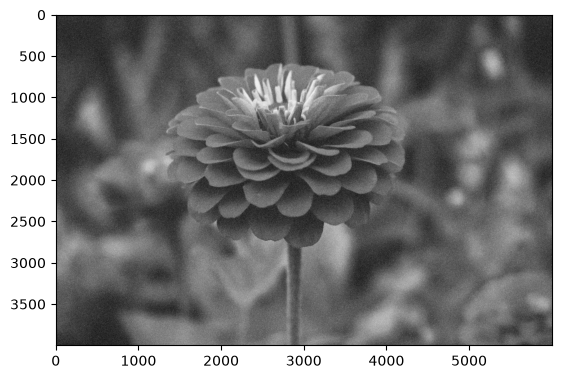

In [4]:
plt.imshow(image_noise_gauss, cmap="gray")

In [5]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim_gauss)

4498.495616958333 0.025890101157439005


# Постоянный шум

In [6]:
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

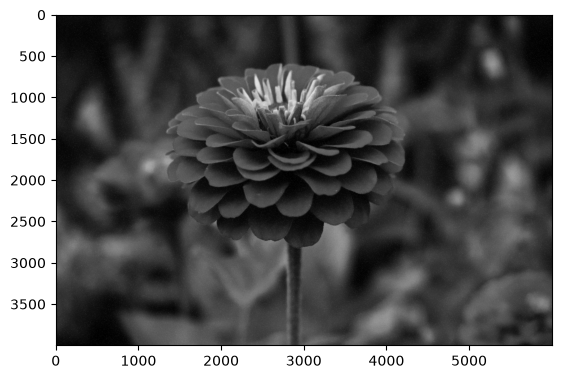

In [7]:
plt.imshow(image_sp, cmap="gray")

In [8]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

445.6462588333333 0.5494566522097792


# Медианный фильтр

In [9]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

844.0684315833333 0.1536194148874991


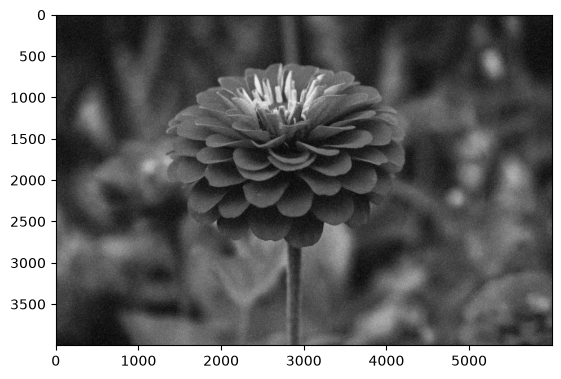

In [10]:
plt.imshow(image_gauss_median, cmap="gray")

In [11]:
image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median_5)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median_5, full=True)
print(mse_gauss_median, ssim_gauss_median)

333.2517864166667 0.36576247704714865


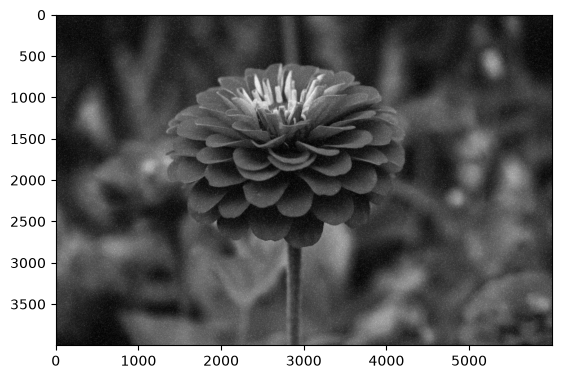

In [12]:
plt.imshow(image_gauss_median_5, cmap="gray")

In [13]:
image_sp_median = cv2.medianBlur(image_sp, 3)
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

7.713124083333334 0.9115606239449541


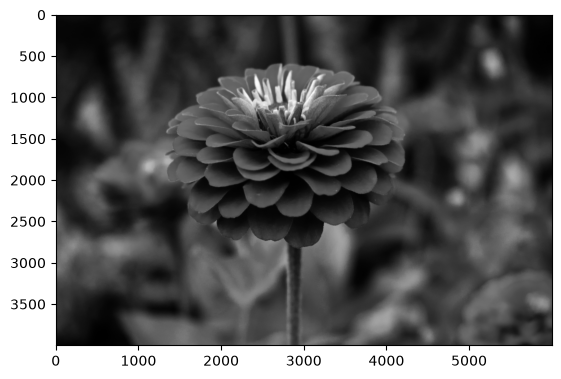

In [14]:
plt.imshow(image_sp_median, cmap="gray")

In [15]:
image_sp_median_5 = cv2.medianBlur(image_sp, 5)
mse_sp_median = mean_squared_error(image_gray, image_sp_median_5)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median_5, full=True)
print(mse_sp_median, ssim_sp_median)

12.045827458333333 0.8562134214032197


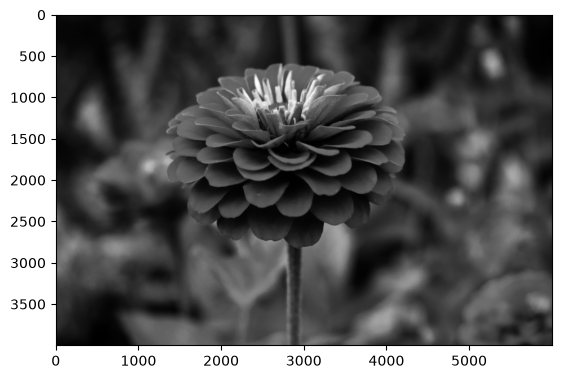

In [16]:
plt.imshow(image_sp_median_5, cmap="gray")

# Фильтр Гаусса

In [17]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (3,3), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1926.513640625 0.14123068983097767


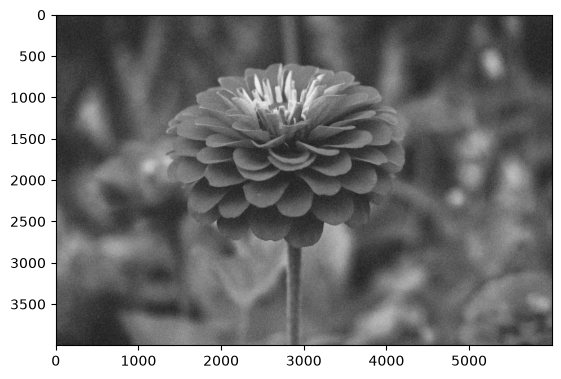

In [18]:
plt.imshow(image_gauss_gauss, cmap="gray")

In [19]:
image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1729.2054128333334 0.2304045520784348


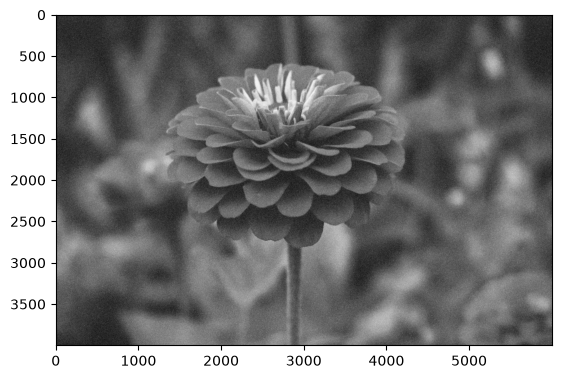

In [20]:
plt.imshow(image_gauss_gauss_5, cmap="gray")

In [21]:
image_sp_gauss = cv2.GaussianBlur(image_sp, (3,3), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

69.85552525 0.6619856562173136


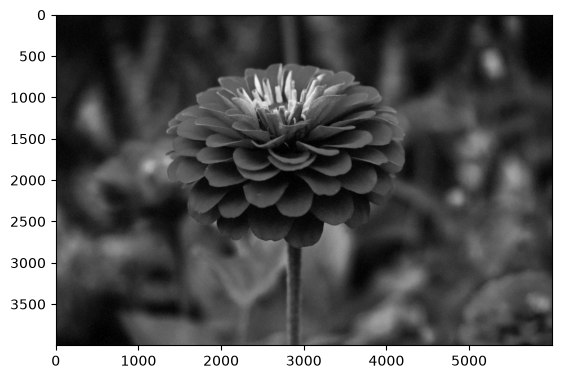

In [22]:
plt.imshow(image_sp_gauss, cmap="gray")

In [23]:
image_sp_gauss_5 = cv2.GaussianBlur(image_sp, (5,5), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss_5)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss_5, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

43.328287875 0.7126111636756266


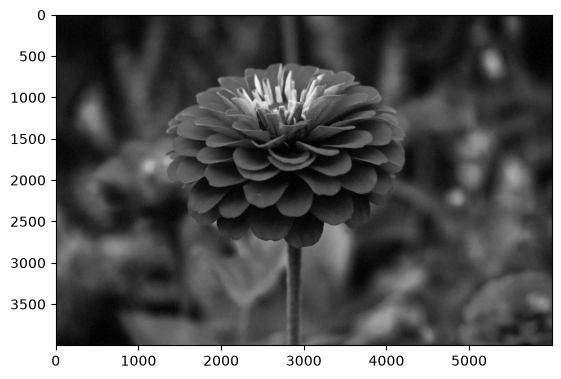

In [24]:
plt.imshow(image_sp_gauss_5, cmap="gray")

# Билатеральный фильтр

In [25]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1786.3903612083334 0.1045069515651392


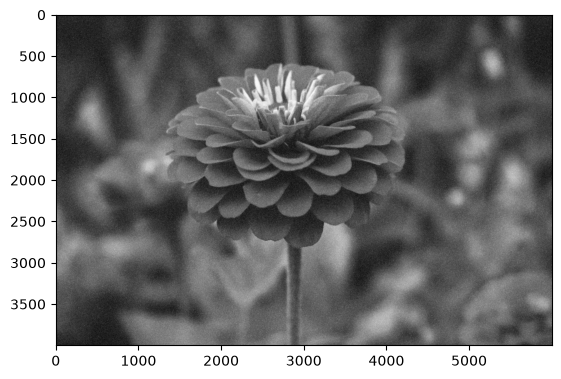

In [26]:
plt.imshow(image_gauss_bilat, cmap="gray")

In [27]:
image_gauss_bilat_150 = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat_150)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat_150, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1362.982392375 0.3525109210916518


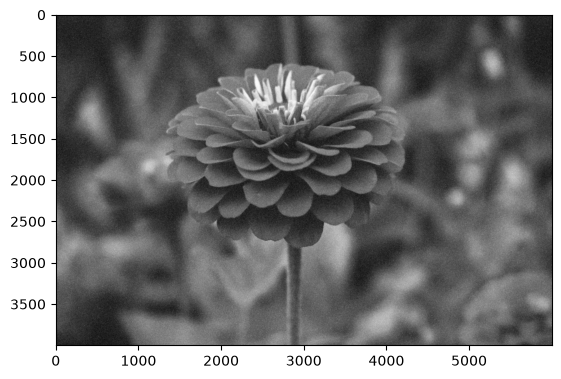

In [28]:
plt.imshow(image_gauss_bilat_150, cmap="gray")

In [29]:
image_sp_bilat = cv2.bilateralFilter(image_sp, 9, 75, 75)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

171.56475645833333 0.6292820663922255


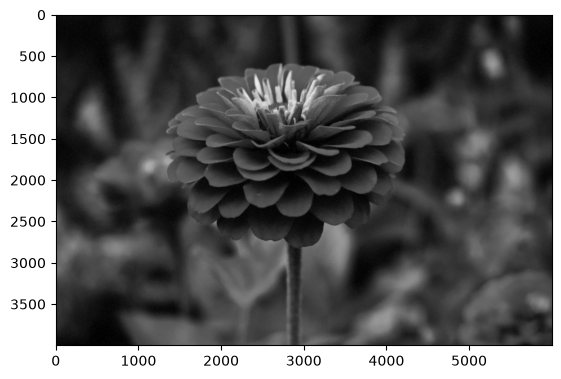

In [30]:
plt.imshow(image_sp_bilat, cmap="gray")

In [42]:
image_sp_bilat_150 = cv2.bilateralFilter(image_sp, 9, 150, 150)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat_150)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat_150, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

16.94947875 0.8192919170308585


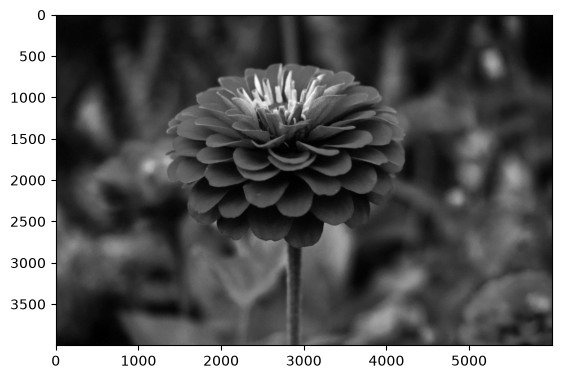

In [43]:
plt.imshow(image_sp_bilat_150, cmap="gray")

# Фильтр нелокальных средних

In [44]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 10)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4498.358609625 0.02608514366593419


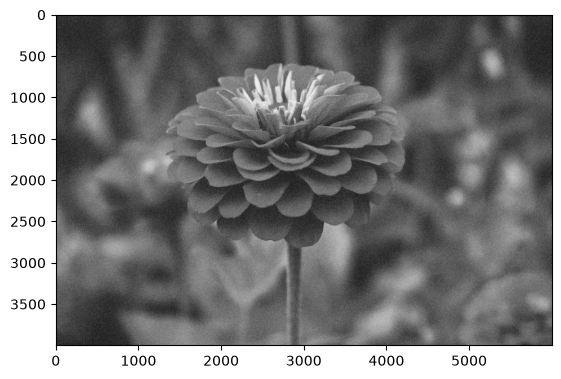

In [45]:
plt.imshow(image_gauss_nlm, cmap="gray")

In [46]:
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm_20)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4486.269640875 0.028931002176420983


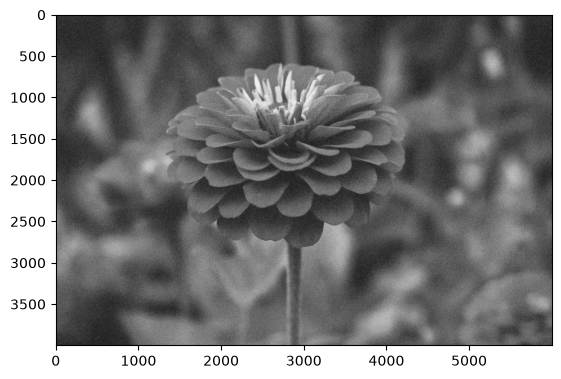

In [47]:
plt.imshow(image_gauss_nlm_20, cmap="gray")

In [48]:
image_sp_nlm = cv2.fastNlMeansDenoising(image_sp, h = 10)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

420.0463882916667 0.5541361607831978


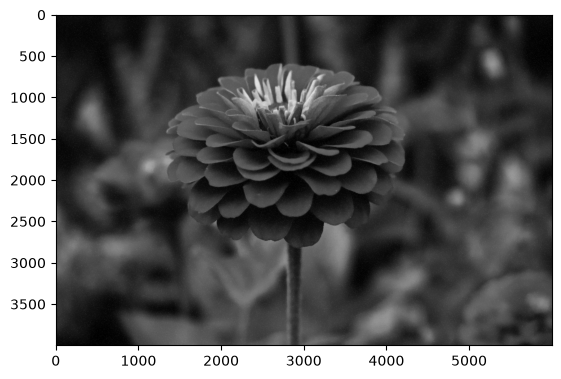

In [49]:
plt.imshow(image_sp_nlm, cmap="gray")

In [50]:
image_sp_nlm_20 = cv2.fastNlMeansDenoising(image_sp, h = 20)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm_20)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm_20, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

64.010052875 0.7505296566001509


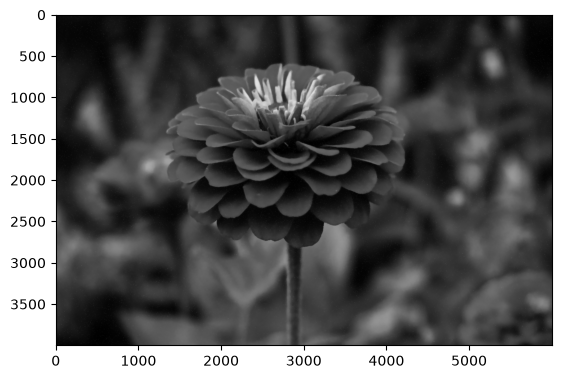

In [51]:
plt.imshow(image_sp_nlm_20, cmap="gray")

# Сравнение фильтров

# Сравнение фильтров по MSE и SSIM

## Для шума Гаусса

| Фильтр | Параметр | MSE | SSIM |
|---|---|---|---|
| Медианный | 3 | 844.0684 | 0.1536 |
| Медианный | 5 | **333.2518** | **0.3658** |
| Гаусса | 3 | 1926.5136 | 0.1412 |
| Гаусса | 5 | 1729.2054 | 0.2304 |
| Билатеральный | 9, 75, 75 | 1362.9824 | 0.3525 |
| Билатеральный | 9, 150, 150 | 1786.3904 | 0.1045 |
| Нелокальных средних | 10 | 4498.3586 | 0.0261 |
| Нелокальных средних | 20 | 4486.2696 | 0.0289 |

**Лучший: Медианный фильтр, параметр 5** (MSE = 333.25, SSIM = 0.3658)

---

## Для постоянного шума

| Фильтр | Параметр | MSE | SSIM |
|---|---|---|---|
| Медианный | 3 | **7.7131** | **0.9116** |
| Медианный | 5 | 12.0458 | 0.8562 |
| Гаусса | 3 | 69.8555 | 0.6620 |
| Гаусса | 5 | 43.3283 | 0.7126 |
| Билатеральный | 9, 75, 75 | 171.5648 | 0.6293 |
| Билатеральный | 9, 150, 150 | 16.9495 | 0.8193 |
| Нелокальных средних | 10 | 420.0464 | 0.5541 |
| Нелокальных средних | 20 | 64.0101 | 0.7505 |

**Лучший: Медианный фильтр, параметр 3** (MSE = 7.71, SSIM = 0.9116)

